# ROI step-by-step: vom Originalbild zur Patch-Extraktion + Rotation

Dieses Notebook zeigt:
1. Originalbild laden und anzeigen  
2. Filter-/Score-Komponenten einzeln (mit Parametern aus `configs/roi_tuner_params.json`)  
3. Finale ROI-Auswahl: Heatmap + Sliding-Window-Scoring (Coarse-to-Fine, NMS)  
4. Originalbild mit gelben ROI-Boxen  
5. 1–2 Beispielpatches ohne Rotation und 1–2 mit Rotation


## Imports & Pfade
In dieser Zelle werden alle benötigten Bibliotheken importiert (`cv2`, `numpy`, `matplotlib`, etc.).  
Zusätzlich wird eine Funktion `find_repo_root()` definiert, die vom aktuellen Notebook-Verzeichnis aus nach oben läuft und einen Ordner sucht, der typisch für euer Projekt ist (z.B. `configs/` und `src/`).  
Damit funktionieren relative Pfade im Notebook zuverlässig, egal ob du das Notebook aus `notebooks/` oder vom Repo-Root aus startest. Danach werden die wichtigsten Pfade gesetzt (Config, Default-Image-Ordner, Output-Ordner) und zur Kontrolle ausgegeben.


In [2]:
from __future__ import annotations

import json
import math
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    """
    Sucht nach einem Repo-Root, indem nach typischen Ordnern gesucht wird.
    Funktioniert sowohl, wenn das Notebook aus /notebooks oder aus Repo-Root gestartet wird.
    """
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "configs").exists() and (p / "src").exists():
            return p
        if (p / "README.md").exists() and (p / "configs").exists():
            return p
    # fallback: eine Ebene hoch
    return start.parent.resolve()


NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = find_repo_root(NOTEBOOK_DIR)

CONFIG_PATH = REPO_ROOT / "configs" / "roi_tuner_params.json"

# Standard: nimm erstes Bild aus data/raw, kann unten überschrieben werden
DEFAULT_IMAGE_DIR = REPO_ROOT / "data" / "raw"

OUT_DIR = REPO_ROOT / "runs" / "roi_step_by_step_debug"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("REPO_ROOT:", REPO_ROOT)
print("CONFIG_PATH:", CONFIG_PATH)
print("DEFAULT_IMAGE_DIR:", DEFAULT_IMAGE_DIR)
print("OUT_DIR:", OUT_DIR)


NOTEBOOK_DIR: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/notebooks
REPO_ROOT: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn
CONFIG_PATH: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/configs/roi_tuner_params.json
DEFAULT_IMAGE_DIR: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/data/raw
OUT_DIR: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/runs/roi_step_by_step_debug


## Config laden (roi_tuner_params.json) + Parameter ausgeben
Hier wird ein Dataclass-Container `RoiTunerParams` definiert, der alle relevanten Parameter (Patch-Größe, Sliding-Window-Parameter, Filter-Grenzen, Gewichte) strukturiert hält.  
Die Funktion `load_params()` lädt die JSON-Datei `configs/roi_tuner_params.json` und überschreibt die Defaultwerte, falls die Keys im JSON vorhanden sind.  
Das Ergebnis (`P`) wird am Ende als JSON formatiert ausgegeben, damit du sofort siehst, mit welchen Parametern alle folgenden Zellen arbeiten.


In [3]:
@dataclass
class RoiTunerParams:
    # entspricht (weitgehend) GuiParams aus roi_tuner_gui.py
    patch_size: int = 265

    score_max_dim: int = 1600

    win_min: int = 128
    win_max: int = 320
    n_scales: int = 3

    stride_coarse: int = 96
    stride_fine: int = 24
    refine_radius: int = 80
    top_k_coarse: int = 60
    top_k_fine_each: int = 20
    top_k_final: int = 120
    iou_thresh: float = 0.25
    score_thr: float = 0.35

    w_edges: float = 1.00
    w_corners: float = 0.70
    w_grad: float = 0.60
    w_aniso: float = 0.80

    canny_low: int = 50
    canny_high: int = 150

    harris_k: float = 0.04
    harris_thr_rel: float = 0.01

    st_sigma: float = 2.0


def load_params(path: Path) -> RoiTunerParams:
    P = RoiTunerParams()
    if path.exists():
        data = json.loads(path.read_text(encoding="utf-8"))
        for k, v in data.items():
            if hasattr(P, k):
                setattr(P, k, v)
        print(f"[OK] Config geladen: {path}")
    else:
        print(f"[WARN] Config nicht gefunden: {path} -> nutze Defaults")
    return P


P = load_params(CONFIG_PATH)
print(json.dumps(asdict(P), indent=2))


[OK] Config geladen: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/configs/roi_tuner_params.json
{
  "patch_size": 265,
  "score_max_dim": 3200,
  "win_min": 28,
  "win_max": 520,
  "n_scales": 5,
  "stride_coarse": 48,
  "stride_fine": 16,
  "refine_radius": 140,
  "top_k_coarse": 180,
  "top_k_fine_each": 25,
  "top_k_final": 250,
  "iou_thresh": 0.22,
  "score_thr": 0.22,
  "w_edges": 0.75,
  "w_corners": 1.6,
  "w_grad": 0.45,
  "w_aniso": 1.6,
  "canny_low": 30,
  "canny_high": 110,
  "harris_k": 0.04,
  "harris_thr_rel": 0.0045,
  "st_sigma": 1.6
}



## Bild auswählen, laden, anzeigen (Originalbild)
Diese Zelle:
1. Sucht automatisch Bilddateien in `data/raw` (oder nutzt eine manuell gesetzte Bilddatei).
2. Lädt das Bild via OpenCV (`cv2.imread`), konvertiert von BGR nach RGB (für matplotlib).
3. Gibt das Originalbild als ersten “Ground Truth”-Output aus.  
Das ist wichtig, weil du später alle Heatmaps und ROI-Boxen auf dieses Originalbild zurückbeziehst.


IMAGE_PATH: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/data/raw/IMG_8450.jpeg


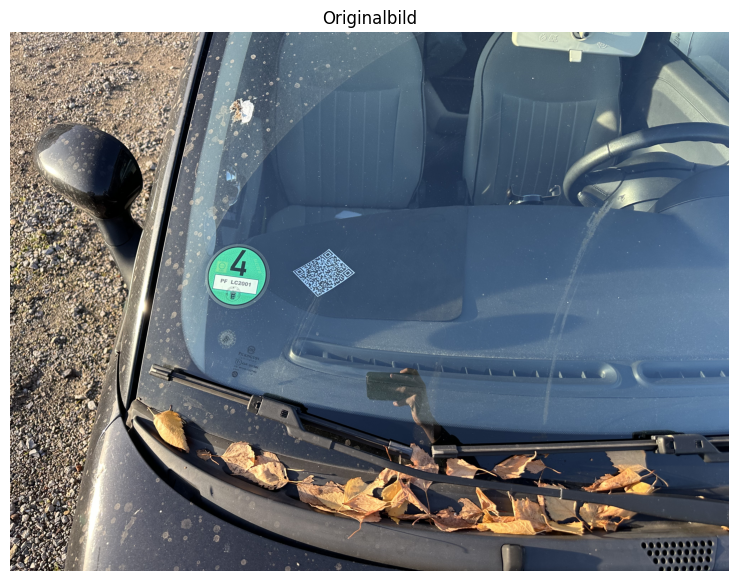

In [4]:
def iter_image_files(input_path: Path) -> List[Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    if input_path.is_file():
        return [input_path] if input_path.suffix.lower() in exts else []
    out = []
    for p in sorted(input_path.rglob("*")):
        if p.is_file() and p.suffix.lower() in exts:
            out.append(p)
    return out


# ---- Bildquelle wählen ----
# Option A: automatisch erstes Bild aus data/raw
candidates = iter_image_files(DEFAULT_IMAGE_DIR)

# Option B: manuell setzen (falls du ein konkretes Bild willst)
# IMAGE_PATH = REPO_ROOT / "data" / "raw" / "dein_bild.jpg"

if not candidates:
    raise FileNotFoundError(f"Keine Bilder gefunden in: {DEFAULT_IMAGE_DIR}")

# IMAGE_PATH = candidates[0]
IMAGE_PATH = REPO_ROOT / "data" / "raw" / "IMG_8450.jpeg"

print("IMAGE_PATH:", IMAGE_PATH)

img_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise ValueError(f"Bild nicht lesbar: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(img_rgb)
plt.title("Originalbild")
plt.axis("off")
plt.show()



## Helpers: Resize, Normalize, Visualisierung
Hier werden Hilfsfunktionen definiert, die in späteren Schritten gebraucht:
- `resize_max_dim`: skaliert ein Bild so, dass die längste Kante `max_dim` nicht überschreitet (schnelleres Scoring).
- `normalize01`: normalisiert beliebige Score-Maps stabil nach `[0..1]` (wichtig für Vergleichbarkeit + Visualisierung).
- `show_gray` / `show_rgb`: Convenience-Funktionen für schnelle, konsistente Plots.  
Diese Zelle verändert noch nichts am Bild, sie baut nur wiederverwendbare Utilities.


In [5]:
def resize_max_dim(img: np.ndarray, max_dim: int) -> Tuple[np.ndarray, float]:
    h, w = img.shape[:2]
    m = max(h, w)
    if m <= max_dim:
        return img, 1.0
    s = max_dim / float(m)
    out = cv2.resize(img, (int(w * s), int(h * s)), interpolation=cv2.INTER_AREA)
    return out, s


def normalize01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mn, mx = float(x.min()), float(x.max())
    if mx - mn < 1e-6:
        return np.zeros_like(x, dtype=np.float32)
    return (x - mn) / (mx - mn)


def show_gray(im: np.ndarray, title: str, figsize=(10, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(im, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_rgb(im_rgb: np.ndarray, title: str, figsize=(10, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(im_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()



## Filter/Score-Komponenten einzeln berechnen
Diese Zelle ist der Kern, um zu verstehen *warum* ROIs später gewählt werden.  
Ablauf:

### 5.1 Vorverarbeitung
- Das Originalbild wird in Graustufen umgewandelt (`gray`), weil Kanten/Gradienten/Struktur in der Regel auf Intensitäten arbeiten.
- Es wird ein “Scoring-Resize” durchgeführt (`score_max_dim`), um das Sliding-Window-Scoring effizient zu machen. Dabei wird der Skalierungsfaktor `s` gespeichert, um später ROIs wieder ins Originalbild zurückzurechnen.
- Ein leichter Gaussian Blur (`cv2.GaussianBlur`) reduziert Bildrauschen, damit Kanten- und Gradientendetektoren stabiler sind (weniger “salt&pepper edges”).

### 5.2 Filter 1: Canny Edges (Kanten)
**Warum?** Kanten zeigen starke Struktur (Kontrastwechsel) und sind oft ein Indikator dafür, dass eine Region “informativ” ist (z.B. Text, QR-Rahmen, Linien, Übergänge).  
**Wie funktioniert’s?**
1. Gradient-Berechnung → Richtung/Stärke
2. Non-Maximum-Suppression → dünne Kanten
3. Hysterese-Schwellen (`canny_low`, `canny_high`) → “starke Kanten bleiben, schwache nur wenn verbunden”  
Output: binäre Edge-Map (0/255), danach in `[0..1]` normiert (`edges01`).

### 5.3 Filter 2: Harris Corners (Ecken)
**Warum?** Ecken sind “2D-Strukturpunkte”: dort ändern sich Intensitäten in *mehr als einer Richtung*.  
QR-Codes / textartige Muster enthalten typischerweise viele Ecken (z.B. Kachelstruktur, Finder-Patterns).  
**Wie funktioniert’s?**
- Harris misst lokale Autokorrelation:  
  wenn Intensitätsänderung in x- UND y-Richtung hoch ist → Corner Response hoch.
- Parameter: `harris_k` steuert, wie stark Kanten vs Ecken bevorzugt werden.
- Danach wird dilated (damit Peaks stärker zusammenhängend sichtbar sind).
- Thresholding über `harris_thr_rel * max_response` macht daraus eine binäre Corner-Maske.  
Output: `corners01` (0 oder 1). Fürs Debug wird eine Corner-Visualisierung ausgegeben.

### 5.4 Filter 3: Gradient Magnitude (Kantenstärke allgemein)
**Warum?** Canny ist binär und threshold-basiert. Gradient Magnitude liefert eine “weiche” Information:  
Wo ist generell viel Kontrast/Struktur – auch wenn Canny dort evtl. nicht “anschlägt”.  
Das stabilisiert das Scoring, weil “leicht strukturierte” Regionen trotzdem erkennbar bleiben.  
**Wie funktioniert’s?**
- Sobel-Filter in x und y (`dx`, `dy`) approximieren Ableitungen.
- Betrag `sqrt(dx² + dy²)` ergibt Gradientenstärke.
- Danach Normalisierung auf `[0..1]` → `mag01`.

### 5.5 Filter 4: Structure Tensor Anisotropy (Richtungsstruktur)
**Warum?** Dieser Teil erkennt, ob eine Region “gerichtete Struktur” besitzt:  
- Hohe Anisotropie bedeutet: starke Struktur in einer dominanten Richtung (z.B. Textlinien, Kantenbündel).
- Niedrige Anisotropie bedeutet: eher isotrop (z.B. glatte Fläche, gleichmäßiges Rauschen).  
Für QR-/Text-artige Bereiche kann das hilfreich sein, weil sich strukturierte Muster deutlich von homogener Windschutzscheibe abheben.

**Wie funktioniert’s?**
- Aus den Gradienten (`dx`, `dy`) werden Produkte gebildet: `Jxx=dx²`, `Jyy=dy²`, `Jxy=dx*dy`.
- Diese werden geglättet (Gaussian) → lokale Mittelung im Fenster (`st_sigma`).
- Daraus wird pro Pixel eine 2x2 Matrix (Structure Tensor) beschrieben.
- Eigenwerte `λ1, λ2` (größte/kleinste Strukturenergie) werden analytisch berechnet.
- Anisotropie = `(λ1 - λ2)/(λ1 + λ2)` → hoch, wenn eine Richtung dominiert.  
Output: normalisiert `aniso01`.

### 5.6 Zwischenausgaben
Nach jedem Filter wird ein separater Output geplottet, damit du direkt siehst:
- was der Filter “markiert”
- wie Parameter (Schwellen, sigma, etc.) das Bild beeinflussen  
Diese Zelle ist besonders wichtig, weil genau diese vier Karten später gewichtet zur Score-Map kombiniert werden.


Resize fürs Scoring: scale s=0.7937 (score_max_dim=3200)
Filter-Parameter aus Config:
- Canny: low=30, high=110
- Harris: k=0.04, thr_rel=0.0045
- ST sigma: 1.6
- Weights: edges=0.75, corners=1.6, grad=0.45, aniso=1.6


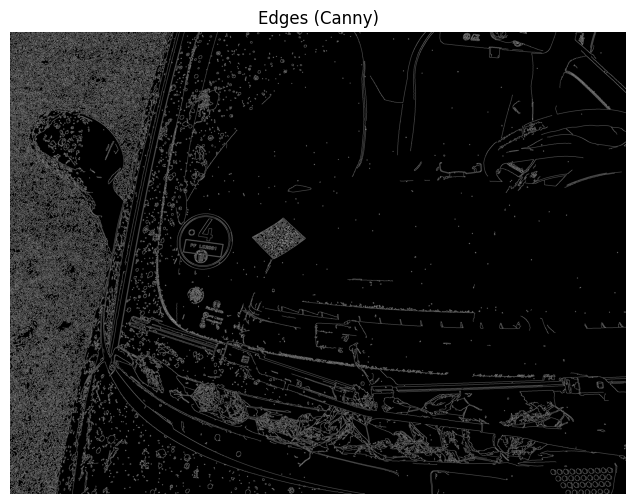

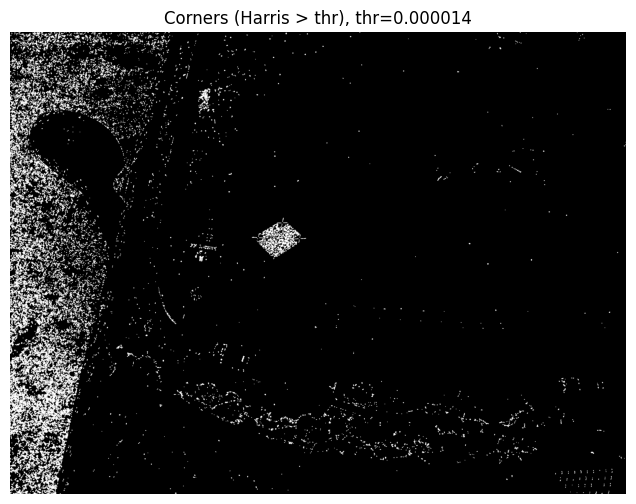

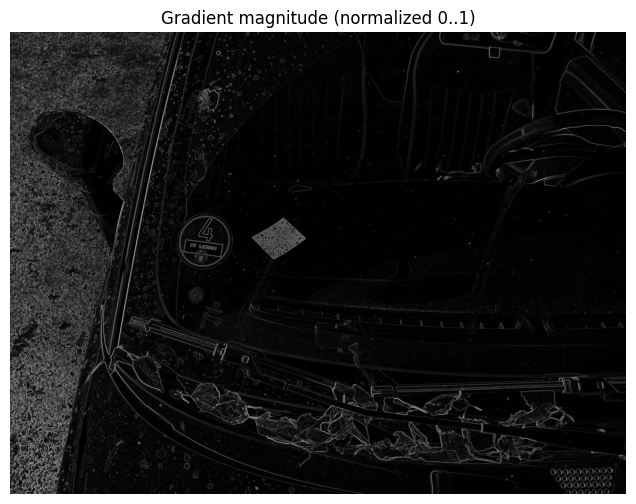

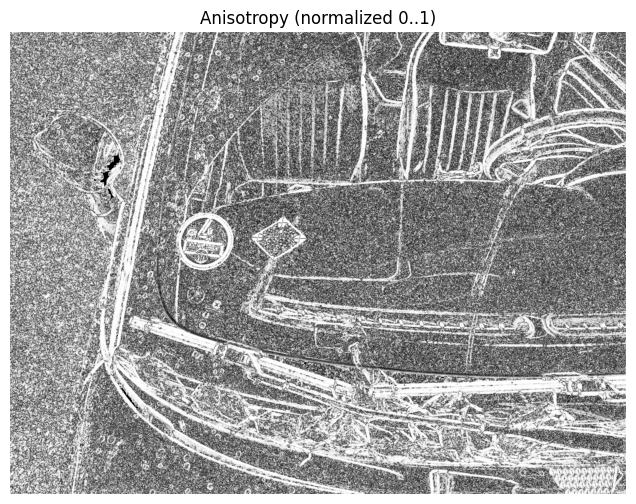

In [6]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

gray_s, s = resize_max_dim(gray, int(P.score_max_dim))
print(f"Resize fürs Scoring: scale s={s:.4f} (score_max_dim={P.score_max_dim})")
print("Filter-Parameter aus Config:")
print(f"- Canny: low={P.canny_low}, high={P.canny_high}")
print(f"- Harris: k={P.harris_k}, thr_rel={P.harris_thr_rel}")
print(f"- ST sigma: {P.st_sigma}")
print(f"- Weights: edges={P.w_edges}, corners={P.w_corners}, grad={P.w_grad}, aniso={P.w_aniso}")

g = cv2.GaussianBlur(gray_s, (5, 5), 0)

# --- 1) Edges (Canny) ---
edges = cv2.Canny(g, int(P.canny_low), int(P.canny_high))
edges01 = edges.astype(np.float32) / 255.0
show_gray(edges, "Edges (Canny)")

# --- 2) Corners (Harris) ---
g32 = (g.astype(np.float32) / 255.0)
harris = cv2.cornerHarris(g32, blockSize=2, ksize=3, k=float(P.harris_k))
harris = cv2.dilate(harris, None)
thr = float(P.harris_thr_rel) * float(harris.max()) if float(harris.max()) > 0 else 0.0
corners01 = (harris > thr).astype(np.float32)

# fürs Display: corners als weiß/schwarz
corners_vis = (corners01 * 255).astype(np.uint8)
show_gray(corners_vis, f"Corners (Harris > thr), thr={thr:.6f}")

# --- 3) Gradient magnitude ---
dx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
dy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
mag = cv2.magnitude(dx, dy)
mag01 = normalize01(mag)
show_gray(mag01, "Gradient magnitude (normalized 0..1)")

# --- 4) Structure-tensor anisotropy (rotation-invariant) ---
jxx = dx * dx
jyy = dy * dy
jxy = dx * dy

ksize = int(max(3, round(float(P.st_sigma) * 6))) | 1
jxx = cv2.GaussianBlur(jxx, (ksize, ksize), float(P.st_sigma))
jyy = cv2.GaussianBlur(jyy, (ksize, ksize), float(P.st_sigma))
jxy = cv2.GaussianBlur(jxy, (ksize, ksize), float(P.st_sigma))

tr = jxx + jyy
det = jxx * jyy - jxy * jxy
disc = np.maximum(tr * tr - 4.0 * det, 0.0)
root = np.sqrt(disc)
l1 = 0.5 * (tr + root)
l2 = 0.5 * (tr - root)
aniso = (l1 - l2) / (l1 + l2 + 1e-6)  # 0..1-ish
aniso01 = normalize01(aniso)
show_gray(aniso01, "Anisotropy (normalized 0..1)")


## Finale Score-Map + Heatmap
Hier werden die vier normalisierten Filtermaps zu einer einzigen Score-Map kombiniert:

`score = w_edges*edges + w_corners*corners + w_grad*grad + w_aniso*aniso`

Die Gewichte kommen direkt aus der Config und steuern, welcher Aspekt (Kanten/Ecken/Gradient/Anisotropie) wichtiger ist.  
Danach wird normalisiert (`score01`) und als:
- Graustufen-Score
- farbige JET-Heatmap  
ausgegeben. Zusätzlich wird die Heatmap optional gespeichert.

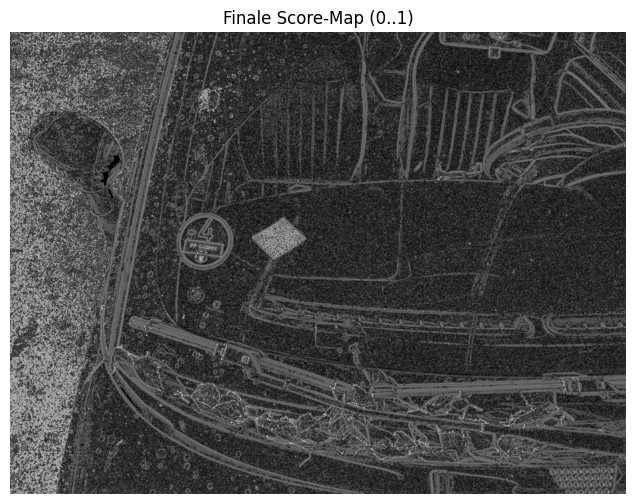

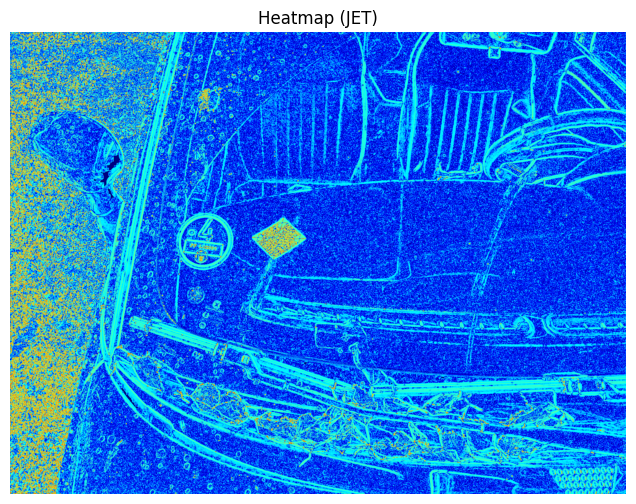

True

In [7]:
score = (
    float(P.w_edges)   * edges01 +
    float(P.w_corners) * corners01 +
    float(P.w_grad)    * mag01 +
    float(P.w_aniso)   * aniso01
)
score01 = normalize01(score)

heat_u8 = (score01 * 255).astype(np.uint8)
heat_bgr = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
heat_rgb = cv2.cvtColor(heat_bgr, cv2.COLOR_BGR2RGB)

show_gray(score01, "Finale Score-Map (0..1)")
show_rgb(heat_rgb, "Heatmap (JET)")

# optional speichern
cv2.imwrite(str(OUT_DIR / f"{IMAGE_PATH.stem}__heatmap.jpg"), heat_bgr)


## Sliding Window / Coarse-to-Fine + NMS (Bewertung)
Diese Zelle macht aus der Score-Map konkrete ROI-Kandidaten:
1. **Integralbild** (`cv2.integral`) wird berechnet, damit Window-Mittelwerte extrem schnell berechnet werden können.
2. **Coarse Scan**: Sliding windows (mehrere Größen `win_sizes`) laufen mit er Schrittweite (`stride_coarse`).
3. **NMS (Non-Maximum Suppression)**: Überlappende Kandidaten werden reduziert, damit nicht 100 fast gleiche ROIs entstehen.
4. **Fine Refinement**: Um die besten coarse Kandidaten wird lokal nochmal fein gescannt (`stride_fine`, `refine_radius`).
5. Final wieder NMS + Top-K Auswahl.

Output ist eine Statistik, wie viele Kandidaten es in jeder Stufe gab und eine kleine Top-Score-Liste.  
Das ist dein “Bewertungs-Output”: du siehst, wie aus Heatmap-Werten echte ROIs werden.



In [8]:
def integral_image(x: np.ndarray) -> np.ndarray:
    return cv2.integral(x)


def window_mean(integ: np.ndarray, x0: int, y0: int, x1: int, y1: int) -> float:
    s_ = float(integ[y1, x1] - integ[y0, x1] - integ[y1, x0] + integ[y0, x0])
    area = float((x1 - x0) * (y1 - y0))
    return s_ / (area + 1e-9)


def iou(a: Tuple[int, int, int, int], b: Tuple[int, int, int, int]) -> float:
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b
    inter_x0 = max(ax0, bx0)
    inter_y0 = max(ay0, by0)
    inter_x1 = min(ax1, bx1)
    inter_y1 = min(ay1, by1)
    iw = max(0, inter_x1 - inter_x0)
    ih = max(0, inter_y1 - inter_y0)
    inter = iw * ih
    if inter == 0:
        return 0.0
    area_a = (ax1 - ax0) * (ay1 - ay0)
    area_b = (bx1 - bx0) * (by1 - by0)
    return inter / float(area_a + area_b - inter + 1e-9)


def nms(cands: List[Dict], iou_thresh: float, top_k: int) -> List[Dict]:
    cands = sorted(cands, key=lambda d: d["score"], reverse=True)
    keep: List[Dict] = []
    for c in cands:
        if len(keep) >= top_k:
            break
        ok = True
        for k in keep:
            if iou(c["box_s"], k["box_s"]) > iou_thresh:
                ok = False
                break
        if ok:
            keep.append(c)
    return keep


def clamp_int(x: int, lo: int, hi: int) -> int:
    return max(lo, min(hi, int(x)))


def make_win_sizes(win_min: int, win_max: int, n_scales: int) -> List[int]:
    win_min = clamp_int(win_min, 32, 512)
    win_max = clamp_int(win_max, 32, 768)
    if win_min > win_max:
        win_min, win_max = win_max, win_min
    n_scales = clamp_int(n_scales, 1, 6)
    if n_scales == 1:
        return [int(win_max)]
    vals = np.linspace(win_min, win_max, n_scales)
    sizes = sorted({int(round(v)) for v in vals})
    return [max(32, s) for s in sizes]


def scan_windows(integ: np.ndarray, win: int, stride: int, score_thr: float, top_k: int) -> List[Dict]:
    h1, w1 = integ.shape[0] - 1, integ.shape[1] - 1
    half = win // 2
    cands: List[Dict] = []
    for cy in range(half, h1 - half, stride):
        for cx in range(half, w1 - half, stride):
            x0, y0 = cx - half, cy - half
            x1, y1 = x0 + win, y0 + win
            m = window_mean(integ, x0, y0, x1, y1)
            if m >= score_thr:
                cands.append({"cx_s": cx, "cy_s": cy, "score": float(m), "win": int(win), "box_s": (x0, y0, x1, y1)})
    cands.sort(key=lambda d: d["score"], reverse=True)
    return cands[:top_k]


def coarse_to_fine(
    score_map: np.ndarray,
    win_sizes: List[int],
    stride_coarse: int,
    stride_fine: int,
    refine_radius: int,
    score_thr: float,
    top_k_coarse: int,
    top_k_fine_each: int,
    iou_thresh: float,
    top_k_final: int,
):
    integ = integral_image(score_map)

    # 1) coarse scan
    coarse_cands: List[Dict] = []
    for win in win_sizes:
        coarse_cands.extend(scan_windows(integ, win, stride_coarse, score_thr, top_k_coarse))

    coarse_pre_nms = list(coarse_cands)
    coarse_cands = nms(coarse_cands, iou_thresh, top_k=max(top_k_coarse, 200))

    # 2) fine refine
    h, w = score_map.shape[:2]
    all_fine: List[Dict] = []

    for c in coarse_cands:
        cx0, cy0, win = c["cx_s"], c["cy_s"], c["win"]
        half = win // 2

        x_min = max(half, cx0 - refine_radius)
        x_max = min(w - half - 1, cx0 + refine_radius)
        y_min = max(half, cy0 - refine_radius)
        y_max = min(h - half - 1, cy0 + refine_radius)

        local: List[Dict] = []
        for cy in range(y_min, y_max + 1, stride_fine):
            for cx in range(x_min, x_max + 1, stride_fine):
                x0, y0 = cx - half, cy - half
                x1, y1 = x0 + win, y0 + win
                m = window_mean(integ, x0, y0, x1, y1)
                if m >= score_thr:
                    local.append({"cx_s": cx, "cy_s": cy, "score": float(m), "win": int(win), "box_s": (x0, y0, x1, y1)})

        local.sort(key=lambda d: d["score"], reverse=True)
        all_fine.extend(local[:top_k_fine_each])

    fine_pre_nms = list(all_fine)
    all_fine.sort(key=lambda d: d["score"], reverse=True)
    final = nms(all_fine, iou_thresh, top_k=top_k_final)

    return coarse_pre_nms, coarse_cands, fine_pre_nms, final


win_sizes = make_win_sizes(int(P.win_min), int(P.win_max), int(P.n_scales))
print("Win sizes (scoring-space):", win_sizes)

coarse_pre, coarse_post, fine_pre, final_s = coarse_to_fine(
    score_map=score01,
    win_sizes=win_sizes,
    stride_coarse=int(P.stride_coarse),
    stride_fine=int(P.stride_fine),
    refine_radius=int(P.refine_radius),
    score_thr=float(P.score_thr),
    top_k_coarse=int(P.top_k_coarse),
    top_k_fine_each=int(P.top_k_fine_each),
    iou_thresh=float(P.iou_thresh),
    top_k_final=int(P.top_k_final),
)

print(f"coarse_pre_nms: {len(coarse_pre)}")
print(f"coarse_post_nms: {len(coarse_post)}")
print(f"fine_pre_nms: {len(fine_pre)}")
print(f"final (post_nms, top_k_final): {len(final_s)}")

# kleine Tabelle der Top-K Final-Kandidaten
for i, c in enumerate(final_s[:10]):
    print(f"{i:02d} score={c['score']:.4f} win={c['win']:3d} center_s=({c['cx_s']},{c['cy_s']})")


Win sizes (scoring-space): [32, 154, 276, 398, 520]
coarse_pre_nms: 900
coarse_post_nms: 200
fine_pre_nms: 5000
final (post_nms, top_k_final): 250
00 score=0.6107 win= 32 center_s=(20,1892)
01 score=0.5987 win= 32 center_s=(292,1972)
02 score=0.5962 win= 32 center_s=(32,1812)
03 score=0.5921 win= 32 center_s=(212,1972)
04 score=0.5919 win= 32 center_s=(48,1956)
05 score=0.5902 win= 32 center_s=(208,2372)
06 score=0.5901 win= 32 center_s=(16,1796)
07 score=0.5884 win= 32 center_s=(180,2068)
08 score=0.5832 win= 32 center_s=(276,1876)
09 score=0.5832 win= 32 center_s=(240,1924)


## Kandidaten visualisieren (Final-Kandidaten als Punkte auf Heatmap)
Hier wird die Heatmap erneut gezeigt, zusätzlich werden die Zentren der finalen Kandidaten als Scatter-Punkte geplottet.  
Damit bekommst du ein sehr intuitives Bild, ob die Auswahl wirklich in den “heißen” Bereichen der Heatmap liegt und wie viele Regionen das System als relevant ansieht.


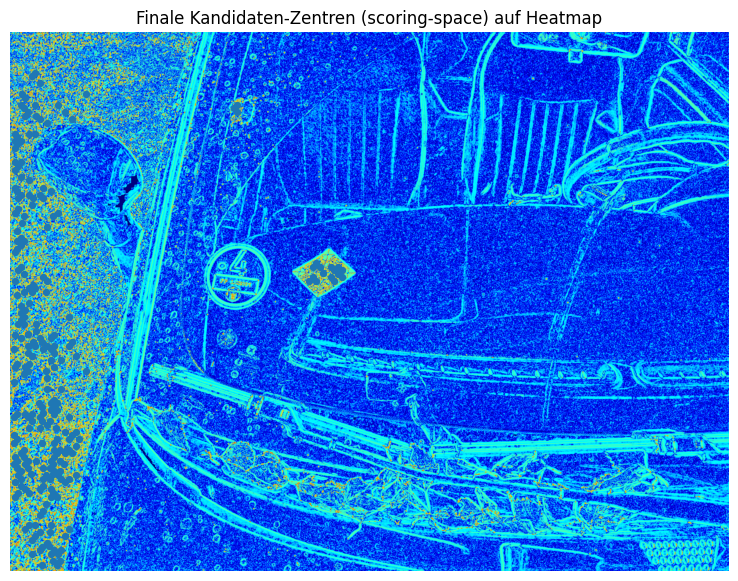

In [9]:
# Scatter-Plot der Final-Kandidaten in scoring-space auf der Heatmap
heat_vis = heat_rgb.copy()

plt.figure(figsize=(10, 7))
plt.imshow(heat_vis)
xs = [c["cx_s"] for c in final_s]
ys = [c["cy_s"] for c in final_s]
plt.scatter(xs, ys, s=18, marker="o")
plt.title("Finale Kandidaten-Zentren (scoring-space) auf Heatmap")
plt.axis("off")
plt.show()


## Final ROIs auf dem Originalbild zeichnen (gelbe Boxen)
Die finalen ROIs sind bisher in “scoring-space” (resize-Resolution).  
In dieser Zelle:
1. werden ROI-Zentren zurück auf Originalbild-Koordinaten gemappt (Division durch `s`).
2. werden Patch-Boxen in der Größe `patch_size` um jedes Zentrum gelegt.
3. werden diese Boxen gelb auf dem Originalbild gezeichnet und mit Score beschriftet.

So bekommst du den geforderten Output: Originalbild mit gelben ROI-Markierungen.


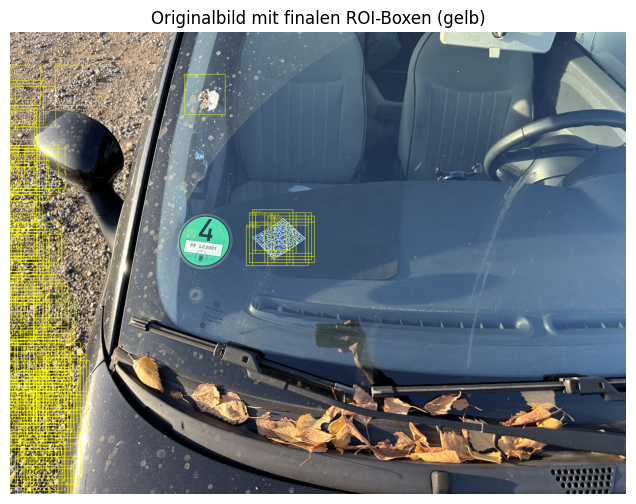

True

In [10]:
def map_to_original(final_s: List[Dict], scale_s: float) -> List[Dict]:
    """
    map scoring-space centers back to original image coords
    """
    out = []
    for c in final_s:
        cx = int(round(c["cx_s"] / scale_s))
        cy = int(round(c["cy_s"] / scale_s))
        out.append({"cx": cx, "cy": cy, "score": float(c["score"]), "win": int(c["win"])})
    return out


final_o = map_to_original(final_s, s)

def draw_boxes(img_bgr: np.ndarray, centers: List[Dict], patch_size: int, max_draw: int = 60) -> np.ndarray:
    out = img_bgr.copy()
    h, w = out.shape[:2]
    half = patch_size // 2
    for i, c in enumerate(centers[:max_draw]):
        cx, cy = int(c["cx"]), int(c["cy"])
        x0, y0 = cx - half, cy - half
        x1, y1 = x0 + patch_size, y0 + patch_size
        x0 = max(0, x0); y0 = max(0, y0); x1 = min(w, x1); y1 = min(h, y1)
        # gelb
        cv2.rectangle(out, (x0, y0), (x1, y1), (0, 255, 255), 2)
        cv2.putText(out, f"{c['score']:.3f}", (x0 + 4, max(15, y0 + 18)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 255), 1, cv2.LINE_AA)
    return out


overlay_bgr = draw_boxes(img_bgr, final_o, int(P.patch_size), max_draw=200)
overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

show_rgb(overlay_rgb, "Originalbild mit finalen ROI-Boxen (gelb)")

cv2.imwrite(str(OUT_DIR / f"{IMAGE_PATH.stem}__overlay_rois.jpg"), overlay_bgr)


## Patches extrahieren (Beispiele ohne Rotation)
Hier werden aus den finalen ROI-Zentren echte Patch-Bilder ausgeschnitten:
- `pad_and_crop` stellt sicher, dass auch ROIs am Rand funktionieren (Reflektions-Padding).
- Es werden 1–2 Top-ROIs genommen und als einzelne Patch-Bilder geplottet.
- Optional werden sie gespeichert.  
Das ist dein “Patch ohne Augmentation”-Referenzoutput.


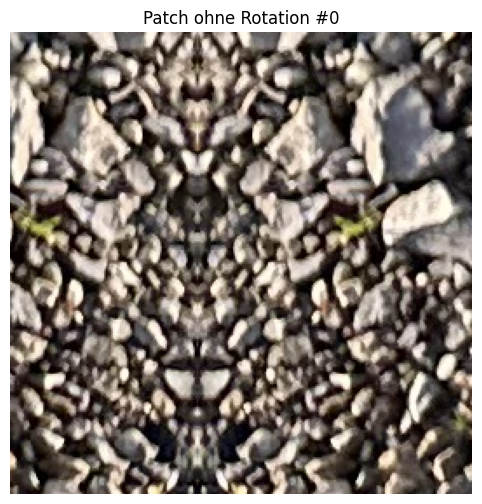

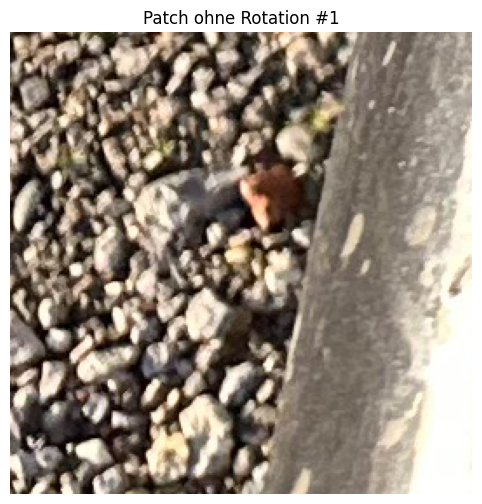

In [11]:
def pad_and_crop(img_bgr: np.ndarray, cx: int, cy: int, patch_size: int) -> np.ndarray:
    """
    Sicherer Crop: wenn ROI nahe Rand liegt, wird reflektiert gepadded.
    """
    h, w = img_bgr.shape[:2]
    half = patch_size // 2
    x0, y0 = cx - half, cy - half
    x1, y1 = x0 + patch_size, y0 + patch_size

    pad_l = max(0, -x0)
    pad_t = max(0, -y0)
    pad_r = max(0, x1 - w)
    pad_b = max(0, y1 - h)

    if pad_l or pad_t or pad_r or pad_b:
        img_bgr = cv2.copyMakeBorder(
            img_bgr, pad_t, pad_b, pad_l, pad_r,
            borderType=cv2.BORDER_REFLECT_101
        )
        x0 += pad_l; x1 += pad_l
        y0 += pad_t; y1 += pad_t

    patch = img_bgr[y0:y1, x0:x1]
    return patch


# 1–2 Beispielpatches (Top-ROIs)
k = min(2, len(final_o))
patches_orig = []
for i in range(k):
    cx, cy = final_o[i]["cx"], final_o[i]["cy"]
    patch = pad_and_crop(img_bgr, cx, cy, int(P.patch_size))
    patches_orig.append(patch)

for i, p_bgr in enumerate(patches_orig):
    show_rgb(cv2.cvtColor(p_bgr, cv2.COLOR_BGR2RGB), f"Patch ohne Rotation #{i}")

    cv2.imwrite(str(OUT_DIR / f"{IMAGE_PATH.stem}__patch_orig_{i}.jpg"), p_bgr)


## Rotation-Augmentierung (Beispiele mit Rotation)
Diese Zelle zeigt, wie Rotation-Augmentierung technisch umgesetzt wird:
1. Es wird berechnet, wie groß ein “Sicherheitsfenster” um die ROI sein muss, damit nach Rotation ein vollständiger Patch ohne abgeschnittene Ecken möglich ist (`rotation_needed_side`).
2. Es wird geprüft, ob diese größere Region vollständig im Bild liegt (`can_rotate_at`).
3. Dann wird:
   - ein großes Quadrat um die ROI ausgeschnitten,
   - rotiert (Affine transform),
   - anschließend ein Center-Crop auf `patch_size` gemacht.

Output: 1–2 rotierte Beispielpatches (mit Winkel im Titel).  
Wichtig: Diese Augmentierung verändert nicht nur “optisch”, sondern macht das Modell robuster gegen leicht gedrehte QR-/Text-Strukturen.


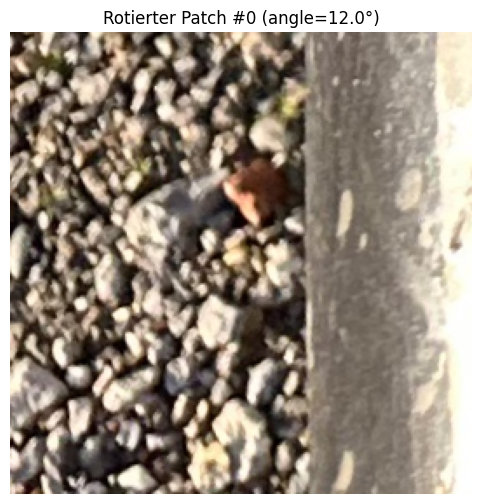

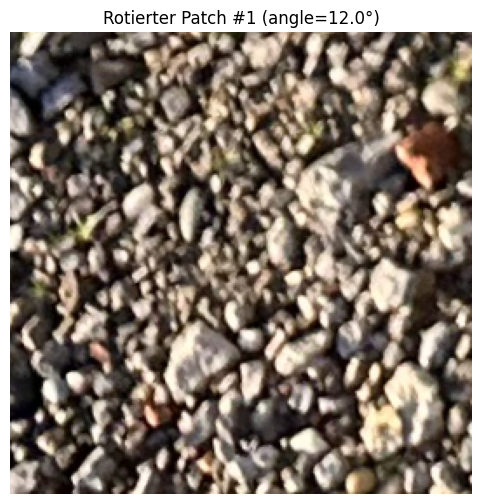

In [12]:
def rotation_needed_side(patch_size: int, angle_deg: float, safety_px: int) -> int:
    theta = math.radians(float(angle_deg))
    c = abs(math.cos(theta))
    s_ = abs(math.sin(theta))
    needed = int(math.ceil(float(patch_size) * (c + s_))) + 2 * int(safety_px)
    needed = max(needed, patch_size)
    if needed % 2 == 0:
        needed += 1
    return needed


def can_rotate_at(img_w: int, img_h: int, cx: int, cy: int, needed_side: int) -> bool:
    half = needed_side // 2
    x0 = cx - half
    y0 = cy - half
    x1 = x0 + needed_side
    y1 = y0 + needed_side
    return (x0 >= 0) and (y0 >= 0) and (x1 <= img_w) and (y1 <= img_h)


def make_rotated_patch(img_bgr: np.ndarray, cx: int, cy: int, patch_size: int, angle_deg: float, needed_side: int):
    h, w = img_bgr.shape[:2]
    if not can_rotate_at(w, h, cx, cy, needed_side):
        return False, None

    half_big = needed_side // 2
    x0 = cx - half_big
    y0 = cy - half_big
    x1 = x0 + needed_side
    y1 = y0 + needed_side

    big = img_bgr[y0:y1, x0:x1]
    if big.shape[0] != needed_side or big.shape[1] != needed_side:
        return False, None

    center = (needed_side / 2.0, needed_side / 2.0)
    M = cv2.getRotationMatrix2D(center, float(angle_deg), 1.0)
    rot_big = cv2.warpAffine(
        big, M, (needed_side, needed_side),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0),
    )

    start = (needed_side - patch_size) // 2
    rot_patch = rot_big[start:start + patch_size, start:start + patch_size]
    if rot_patch.shape[0] != patch_size or rot_patch.shape[1] != patch_size:
        return False, None

    return True, rot_patch


# 1–2 Rotations-Beispiele suchen
rot_examples = []
H, W = img_bgr.shape[:2]

angles_to_try = [12.0, -17.0, 8.0, -10.0]  # fix, damit reproduzierbar
safety_px = 3

for c in final_o:
    if len(rot_examples) >= 2:
        break
    cx, cy = int(c["cx"]), int(c["cy"])
    for ang in angles_to_try:
        needed = rotation_needed_side(int(P.patch_size), ang, safety_px)
        if can_rotate_at(W, H, cx, cy, needed):
            ok, rot_patch = make_rotated_patch(img_bgr, cx, cy, int(P.patch_size), ang, needed)
            if ok:
                rot_examples.append((cx, cy, ang, rot_patch))
                break

if not rot_examples:
    print("[WARN] Keine rotierbaren ROIs gefunden (zu nah am Rand?). Versuch: kleinere Winkel oder anderes Bild.")
else:
    for i, (cx, cy, ang, p_bgr) in enumerate(rot_examples):
        show_rgb(cv2.cvtColor(p_bgr, cv2.COLOR_BGR2RGB), f"Rotierter Patch #{i} (angle={ang}°)")

        cv2.imwrite(str(OUT_DIR / f"{IMAGE_PATH.stem}__patch_rot_{i}__ang_{ang:+.1f}.jpg"), p_bgr)


## Optional: “Warum wurde ROI X gewählt?” (Local Score Surface)
Diese Debug-Zelle visualisiert die lokale Optimierung um einen coarse Kandidaten:
- Es wird in einem lokalen Radius (`refine_radius`) eine Score-Oberfläche berechnet (Window-Mean je Position).
- Diese Oberfläche wird als Heatmap geplottet.  
Du siehst dadurch direkt:
- wo das lokale Maximum liegt,
- wie “flach” oder “spitz” das Maximum ist,
- ob `stride_fine`/`refine_radius` sinnvoll gewählt sind.

Das ist extrem hilfreich, um die Feinabstimmung (Refinement) zu verstehen oder Parameter zu tunen.

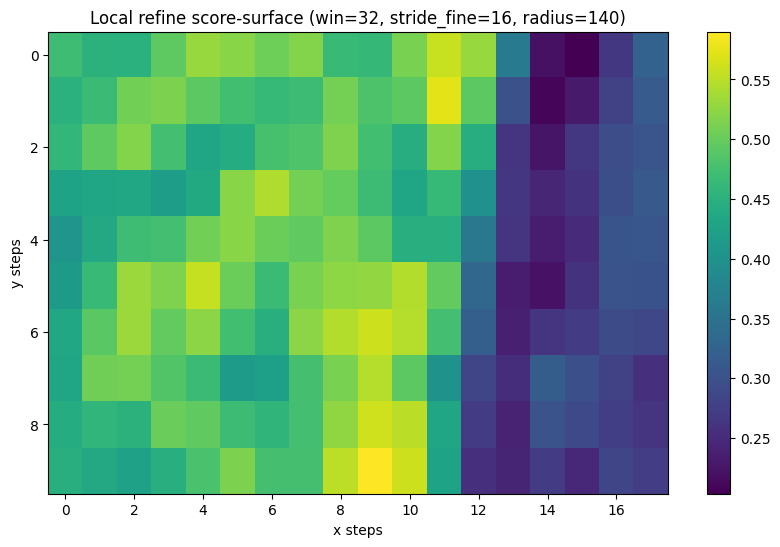

Max local score: 0.5899156928062439


In [13]:
def local_score_surface(score_map: np.ndarray, center_s: Tuple[int,int], win: int, radius: int, stride: int):
    integ = integral_image(score_map)
    h, w = score_map.shape[:2]
    cx0, cy0 = center_s
    half = win // 2

    x_min = max(half, cx0 - radius)
    x_max = min(w - half - 1, cx0 + radius)
    y_min = max(half, cy0 - radius)
    y_max = min(h - half - 1, cy0 + radius)

    xs = list(range(x_min, x_max + 1, stride))
    ys = list(range(y_min, y_max + 1, stride))
    surf = np.zeros((len(ys), len(xs)), dtype=np.float32)

    for yi, cy in enumerate(ys):
        for xi, cx in enumerate(xs):
            x0, y0 = cx - half, cy - half
            x1, y1 = x0 + win, y0 + win
            surf[yi, xi] = window_mean(integ, x0, y0, x1, y1)
    return xs, ys, surf


if coarse_post:
    c0 = coarse_post[0]
    xs, ys, surf = local_score_surface(
        score01,
        center_s=(c0["cx_s"], c0["cy_s"]),
        win=c0["win"],
        radius=int(P.refine_radius),
        stride=int(P.stride_fine),
    )

    plt.figure(figsize=(10, 6))
    plt.imshow(surf, aspect="auto")
    plt.title(f"Local refine score-surface (win={c0['win']}, stride_fine={P.stride_fine}, radius={P.refine_radius})")
    plt.xlabel("x steps")
    plt.ylabel("y steps")
    plt.colorbar()
    plt.show()

    print("Max local score:", float(surf.max()))
